this notebook ... 
dieses Nootbook dient dem Zweck sich eine Übersicht zu erstellen was für Daten in dem Datenset (...) vorliegen. Zu dem soll grundlegendes geklärt werden (zb. Spalten namen ect)

# 1. Imports

In [1]:
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Data

In [2]:
df = pd.read_csv('../data/interim/n2o_ssa_landuse_aligned_combined.csv')

# 3. Basic Dataset Information

In [3]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Total data points: {df.size:,}")

df.describe()

Number of rows: 5,280
Number of columns: 27
Total data points: 142,560


,Latitude,Longitude,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),"Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)",Soil moisture [m**3/m**3] (ERA5 reanalyses),Soil moisture [m**3/m**3] (ERA5 reanalyses).1,...,VPD day m [kPa] (ERA5 reanalyses),PPPP day m [hPa] (ERA5 reanalyses),SWD day m [W/m**2] (ERA5 reanalyses),PPFD day m [µmol/m**2/s] (ERA5 reanalyses),Duration [days] (Since last precipitation even...),Duration [days] (Since last fertiliser applica...),Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05)),Transformation S (Modeled),Transformation C (Modeled),"N2O flux [µg/m**2/h] (From soil surface, Modeled)"
count,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,...,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000,5280.000000
mean,-1.228231,31.331031,38.504735,21.133681,25.754478,17.674016,1.489663,0.315828,0.310683,0.294414,...,0.677221,864.763174,38.194886,77.153669,3.509848,20.852083,15.123450,0.130964,-0.123367,12.095709
std,3.703325,10.765475,46.788347,3.171982,3.514496,3.438315,4.270444,0.106214,0.105178,0.098814,...,0.334093,59.804719,9.087886,18.357529,20.028591,37.419433,30.809558,0.690452,0.700777,20.839097
min,-17.706000,-0.381800,0.000000,13.069766,16.074131,6.959682,0.000000,0.078000,0.078000,0.066000,...,0.049908,789.017518,2.077375,4.196297,0.000000,0.000000,0.000000,-1.000000,-1.000000,-21.149615
25%,-2.139900,32.692700,0.000000,18.666322,22.958315,15.252268,0.001318,0.225582,0.225204,0.219140,...,0.436225,829.737725,32.366683,65.380701,0.000000,0.000000,0.000000,-0.528964,-0.809017,1.896372
50%,-1.260000,35.380000,45.000000,20.614597,25.779030,16.875000,0.130284,0.328086,0.316613,0.300809,...,0.606044,833.091315,38.207133,77.178409,0.000000,2.000000,0.000000,0.283206,-0.283206,5.142646
75%,0.321900,36.720000,50.000000,23.190000,28.127880,19.555776,1.126393,0.401567,0.398310,0.370087,...,0.852115,895.864040,44.725212,90.344926,0.000000,33.000000,14.505386,0.790776,0.557324,13.045997
max,6.054500,38.226900,200.000000,28.942652,35.700000,26.212832,69.000000,0.507654,0.506686,0.510832,...,1.954649,994.700000,59.174045,119.531572,205.000000,251.000000,194.272423,1.000000,1.000000,242.346036


# 4. Column Overview

In [4]:
for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

01. Event
02. Latitude
03. Longitude
04. Date/Time
05. Land use
06. Fert N [kg/ha] (Recorded at time of application)
07. TTT day m [°C] (ERA5 reanalyses)
08. TxTxTx day max [°C] (ERA5 reanalyses)
09. TnTnTn day min [°C] (ERA5 reanalyses)
10. Precip day total [mm/day] (ERA5 reanalyses)
11. Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)
12. Soil moisture [m**3/m**3] (ERA5 reanalyses)
13. Soil moisture [m**3/m**3] (ERA5 reanalyses).1
14. T soil day m [°C] (ERA5 reanalyses)
15. T soil day m [°C] (ERA5 reanalyses).1
16. T soil day m [°C] (ERA5 reanalyses).2
17. Cloud cov [%] (ERA5 reanalyses)
18. VPD day m [kPa] (ERA5 reanalyses)
19. PPPP day m [hPa] (ERA5 reanalyses)
20. SWD day m [W/m**2] (ERA5 reanalyses)
21. PPFD day m [µmol/m**2/s] (ERA5 reanalyses)
22. Duration [days] (Since last precipitation even...)
23. Duration [days] (Since last fertiliser applica...)
24. Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05))
25. Transformation S (Modeled)
26. Transformation 

# 5. Data Types

In [5]:
df.dtypes

Event                                                             object
Latitude                                                         float64
Longitude                                                        float64
Date/Time                                                         object
Land use                                                          object
Fert N [kg/ha] (Recorded at time of application)                   int64
TTT day m [°C] (ERA5 reanalyses)                                 float64
TxTxTx day max [°C] (ERA5 reanalyses)                            float64
TnTnTn day min [°C] (ERA5 reanalyses)                            float64
Precip day total [mm/day] (ERA5 reanalyses)                      float64
Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)     float64
Soil moisture [m**3/m**3] (ERA5 reanalyses)                      float64
Soil moisture [m**3/m**3] (ERA5 reanalyses).1                    float64
T soil day m [°C] (ERA5 reanalyses)                

# 6. Missing Values

In [6]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame(name="missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    by="missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
Event,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Date/Time,0,0.0
Land use,0,0.0
Fert N [kg/ha] (Recorded at time of application),0,0.0
TTT day m [°C] (ERA5 reanalyses),0,0.0
TxTxTx day max [°C] (ERA5 reanalyses),0,0.0
TnTnTn day min [°C] (ERA5 reanalyses),0,0.0
Precip day total [mm/day] (ERA5 reanalyses),0,0.0


# 7. Duplicates

In [7]:
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_rows:,}")
print(f"Share of duplicated rows: {duplicate_rows / len(df) * 100:.2f}%")

Number of duplicated rows: 0
Share of duplicated rows: 0.00%


In [8]:
duplicate_event_date_rows = df.duplicated(
    subset=["Event", "Date/Time"]
).sum()

print(f"Duplicated Event-Date combinations: {duplicate_event_date_rows:,}")

Duplicated Event-Date combinations: 3,226


## 8. Target Variable Overview

In [9]:
TARGET_COLUMN = "N2O flux [µg/m**2/h] (From soil surface, Modeled)"

df[TARGET_COLUMN].describe()

count    5280.000000
mean       12.095709
std        20.839097
min       -21.149615
25%         1.896372
50%         5.142646
75%        13.045997
max       242.346036
Name: N2O flux [µg/m**2/h] (From soil surface, Modeled), dtype: float64

In [10]:
print(f"Minimum N2O flux: {df[TARGET_COLUMN].min():.4f}")
print(f"Maximum N2O flux: {df[TARGET_COLUMN].max():.4f}")
print(f"Mean N2O flux: {df[TARGET_COLUMN].mean():.4f}")
print(f"Median N2O flux: {df[TARGET_COLUMN].median():.4f}")
print(f"Standard deviation: {df[TARGET_COLUMN].std():.4f}")

Minimum N2O flux: -21.1496
Maximum N2O flux: 242.3460
Mean N2O flux: 12.0957
Median N2O flux: 5.1426
Standard deviation: 20.8391


# 9. Histogramm der Zielvariable

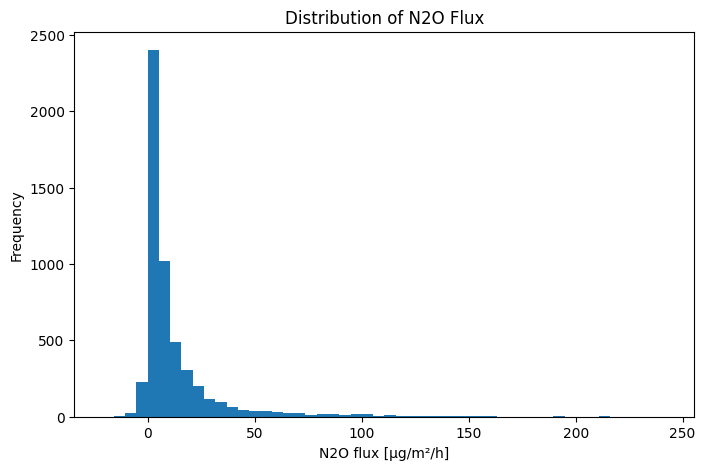

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COLUMN].dropna(), bins=50)
plt.xlabel("N2O flux [µg/m²/h]")
plt.ylabel("Frequency")
plt.title("Distribution of N2O Flux")
plt.show()

weil sehr schief...

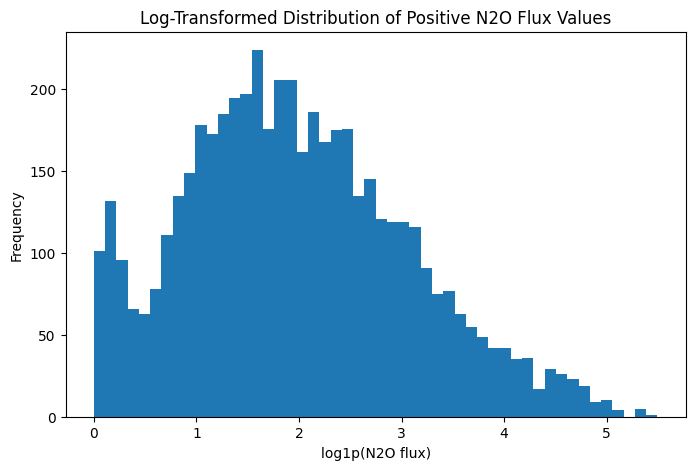

In [12]:
positive_target = df.loc[df[TARGET_COLUMN] > 0, TARGET_COLUMN]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(positive_target), bins=50)
plt.xlabel("log1p(N2O flux)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Positive N2O Flux Values")
plt.show()

# 10. Categorical Variables

In [13]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(categorical_columns)

for column in categorical_columns:
    print("=" * 80)
    print(column)
    print(df[column].value_counts(dropna=False).head(20))



['Event', 'Date/Time', 'Land use']
Event
Event
20SL-Maz         1695
24TO-ELD          483
25RG-SOR4D        396
24RD-Yang         301
15JH-Tumbi        288
19JZ-Mbeya        220
15JH-Yala         212
19JZ-Iringa       212
22MB-Yoko         127
14JH-Maseno       114
22MB-Kahuzi        98
17AG-KILO-FLM      95
17AG-KILO-FOC      90
23ML-MACH          90
23ML-SID           82
20SW-B-Mak         62
20SW-Taita         61
20SW-LUMO          60
20SW-C-Mak         57
25-SOR4D_FP        53
Name: count, dtype: int64
Date/Time
Date/Time
2019-03-02    22
2018-01-11    22
2019-08-08    21
2019-05-08    21
2019-05-04    21
2019-05-02    21
2019-04-11    21
2019-07-04    21
2019-07-10    21
2019-07-06    21
2019-01-11    21
2019-04-01    21
2019-02-12    21
2019-02-09    21
2019-06-04    21
2019-05-12    21
2019-04-04    21
2019-02-04    21
2019-04-02    20
2019-08-06    20
Name: count, dtype: int64
Land use
Land use
Cropland     3574
Forest       1481
Grassland     225
Name: count, dtype: int64


In [14]:
display(df["Land use"].value_counts(dropna=False))
display(df["Event"].value_counts(dropna=False))

Land use
Cropland     3574
Forest       1481
Grassland     225
Name: count, dtype: int64

Event
20SL-Maz          1695
24TO-ELD           483
25RG-SOR4D         396
24RD-Yang          301
15JH-Tumbi         288
19JZ-Mbeya         220
15JH-Yala          212
19JZ-Iringa        212
22MB-Yoko          127
14JH-Maseno        114
22MB-Kahuzi         98
17AG-KILO-FLM       95
17AG-KILO-FOC       90
23ML-MACH           90
23ML-SID            82
20SW-B-Mak          62
20SW-Taita          61
20SW-LUMO           60
20SW-C-Mak          57
25-SOR4D_FP         53
25CA-SOR4D_DAF      45
17AG-KILO-COF       43
18IW-KAP-FR         42
18IW-CHESP-FR       42
18IW-CHESP-TEA      42
18IW-CHESP-GL       42
22MB-Jardin         41
23ML-ALDEK          40
18IW-KAP-TEA        33
18IW-KAP-EUCH       33
23ML-EMB            31
23AS-DTC            25
23AS-UZF            25
Name: count, dtype: int64

# 11. Numeric Variables

In [15]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

numeric_summary = df[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Latitude,5280.0,-1.228231,3.703325,-17.706000,-2.139900,-1.260000,0.321900,6.054500
Longitude,5280.0,31.331031,10.765475,-0.381800,32.692700,35.380000,36.720000,38.226900
Fert N [kg/ha] (Recorded at time of application),5280.0,38.504735,46.788347,0.000000,0.000000,45.000000,50.000000,200.000000
TTT day m [°C] (ERA5 reanalyses),5280.0,21.133681,3.171982,13.069766,18.666322,20.614597,23.190000,28.942652
TxTxTx day max [°C] (ERA5 reanalyses),5280.0,25.754478,3.514496,16.074131,22.958315,25.779030,28.127880,35.700000
TnTnTn day min [°C] (ERA5 reanalyses),5280.0,17.674016,3.438315,6.959682,15.252268,16.875000,19.555776,26.212832
Precip day total [mm/day] (ERA5 reanalyses),5280.0,1.489663,4.270444,0.000000,0.001318,0.130284,1.126393,69.000000
"Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)",5280.0,0.315828,0.106214,0.078000,0.225582,0.328086,0.401567,0.507654
Soil moisture [m**3/m**3] (ERA5 reanalyses),5280.0,0.310683,0.105178,0.078000,0.225204,0.316613,0.398310,0.506686
Soil moisture [m**3/m**3] (ERA5 reanalyses).1,5280.0,0.294414,0.098814,0.066000,0.219140,0.300809,0.370087,0.510832


# 12. Date Range and Temporal Coverage

In [16]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"], errors="coerce")

print(f"Earliest date: {df['Date/Time'].min()}")
print(f"Latest date: {df['Date/Time'].max()}")
print(f"Number of unique dates: {df['Date/Time'].nunique():,}")

Earliest date: 2005-03-27 00:00:00
Latest date: 2025-07-12 00:00:00
Number of unique dates: 1,447


add new time features...

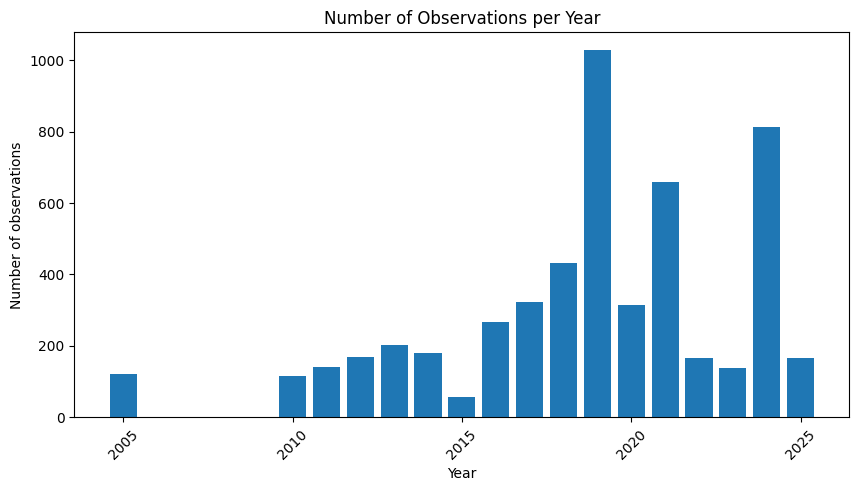

In [17]:
df["year"] = df["Date/Time"].dt.year
df["month"] = df["Date/Time"].dt.month
df["day_of_year"] = df["Date/Time"].dt.dayofyear
df["year"].value_counts().sort_index()
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Number of Observations per Year")
plt.xticks(rotation=45)
plt.show()

# 13. Site and Land-Use Coverage

In [18]:
print(f"Number of unique events/sites: {df['Event'].nunique()}")
print(f"Number of unique land-use classes: {df['Land use'].nunique()}")

Number of unique events/sites: 33
Number of unique land-use classes: 3


## Land use

In [19]:
land_use_counts = df["Land use"].value_counts(dropna=False)

land_use_counts

Land use
Cropland     3574
Forest       1481
Grassland     225
Name: count, dtype: int64

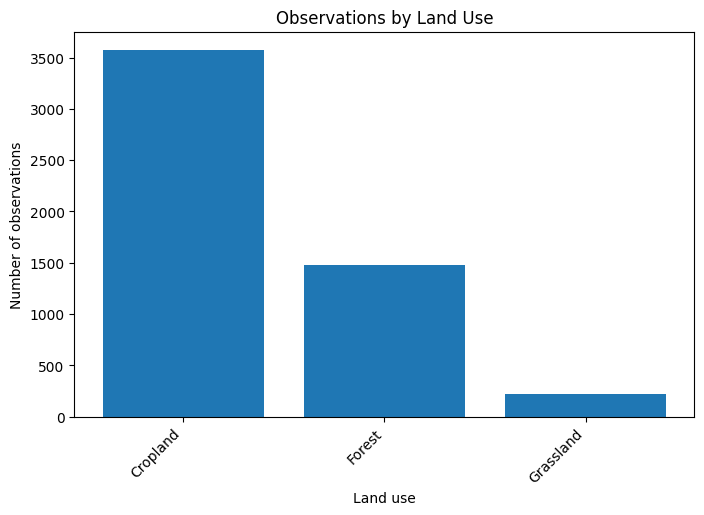

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(land_use_counts.index.astype(str), land_use_counts.values)
plt.xlabel("Land use")
plt.ylabel("Number of observations")
plt.title("Observations by Land Use")
plt.xticks(rotation=45, ha="right")
plt.show()

## Event/Site

Event
20SL-Maz          1695
24TO-ELD           483
25RG-SOR4D         396
24RD-Yang          301
15JH-Tumbi         288
19JZ-Mbeya         220
15JH-Yala          212
19JZ-Iringa        212
22MB-Yoko          127
14JH-Maseno        114
22MB-Kahuzi         98
17AG-KILO-FLM       95
17AG-KILO-FOC       90
23ML-MACH           90
23ML-SID            82
20SW-B-Mak          62
20SW-Taita          61
20SW-LUMO           60
20SW-C-Mak          57
25-SOR4D_FP         53
25CA-SOR4D_DAF      45
17AG-KILO-COF       43
18IW-KAP-FR         42
18IW-CHESP-FR       42
18IW-CHESP-TEA      42
18IW-CHESP-GL       42
22MB-Jardin         41
23ML-ALDEK          40
18IW-KAP-TEA        33
18IW-KAP-EUCH       33
23ML-EMB            31
23AS-DTC            25
23AS-UZF            25
Name: count, dtype: int64


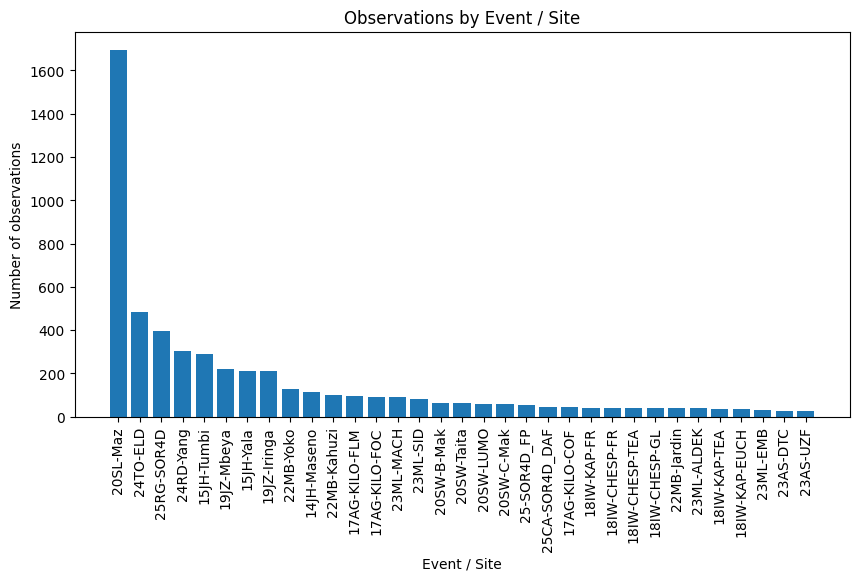

In [21]:
event_counts = df["Event"].value_counts()
print(event_counts)
plt.figure(figsize=(10, 5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xlabel("Event / Site")
plt.ylabel("Number of observations")
plt.title("Observations by Event / Site")
plt.xticks(rotation=90)
plt.show()

# 14. N₂O Flux after Land-use

           count       mean    median        std        min         max
Land use                                                               
Cropland    3574  11.884864  5.508281  20.859414 -21.149615  242.346036
Forest      1481  13.645505  4.712477  21.551667 -11.501391  170.241240
Grassland    225   5.243767  1.470000  12.700628 -11.130000  118.179897


C:\Users\ecslt\AppData\Local\Temp\ipykernel_29152\2632665200.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=land_use_order, showfliers=False)


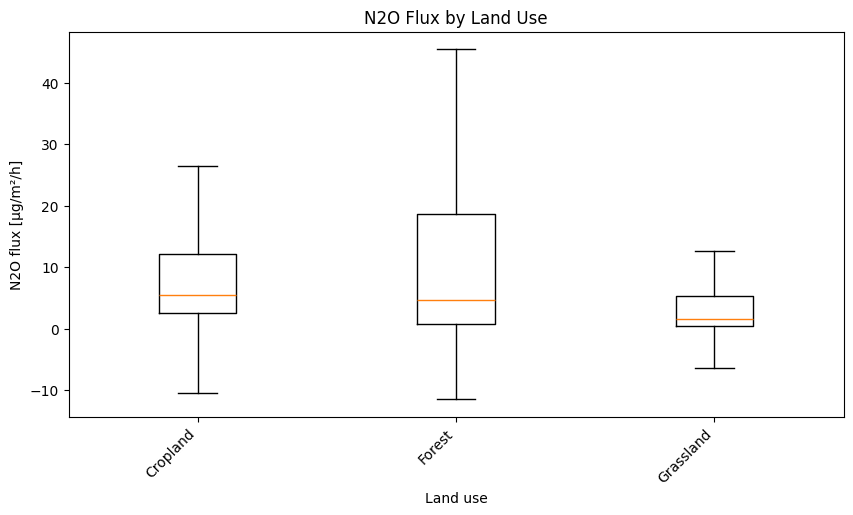

In [22]:
n2o_by_land_use = (
    df.groupby("Land use")[TARGET_COLUMN]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values(by="median", ascending=False)
)

print(n2o_by_land_use)
land_use_order = (
    df.groupby("Land use")[TARGET_COLUMN]
    .median()
    .sort_values(ascending=False)
    .index
)

data_to_plot = [
    df.loc[df["Land use"] == land_use, TARGET_COLUMN].dropna()
    for land_use in land_use_order
]

plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot, labels=land_use_order, showfliers=False)
plt.xlabel("Land use")
plt.ylabel("N2O flux [µg/m²/h]")
plt.title("N2O Flux by Land Use")
plt.xticks(rotation=45, ha="right")
plt.show()

# 15. Korrelationen numerischer Features

In [23]:
correlation_with_target = (
    df[numeric_columns]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .sort_values(ascending=False)
)

correlation_with_target


N2O flux [µg/m**2/h] (From soil surface, Modeled)                1.000000
Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05))    0.110364
Cloud cov [%] (ERA5 reanalyses)                                  0.105158
TnTnTn day min [°C] (ERA5 reanalyses)                            0.090320
Latitude                                                         0.077809
Fert N [kg/ha] (Recorded at time of application)                 0.058045
Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)     0.049978
PPPP day m [hPa] (ERA5 reanalyses)                               0.040859
Soil moisture [m**3/m**3] (ERA5 reanalyses)                      0.039032
T soil day m [°C] (ERA5 reanalyses).2                            0.035421
TTT day m [°C] (ERA5 reanalyses)                                 0.026191
T soil day m [°C] (ERA5 reanalyses).1                            0.024521
Soil moisture [m**3/m**3] (ERA5 reanalyses).1                    0.023540
T soil day m [°C] (ERA5 reanalyses)   

<Axes: >

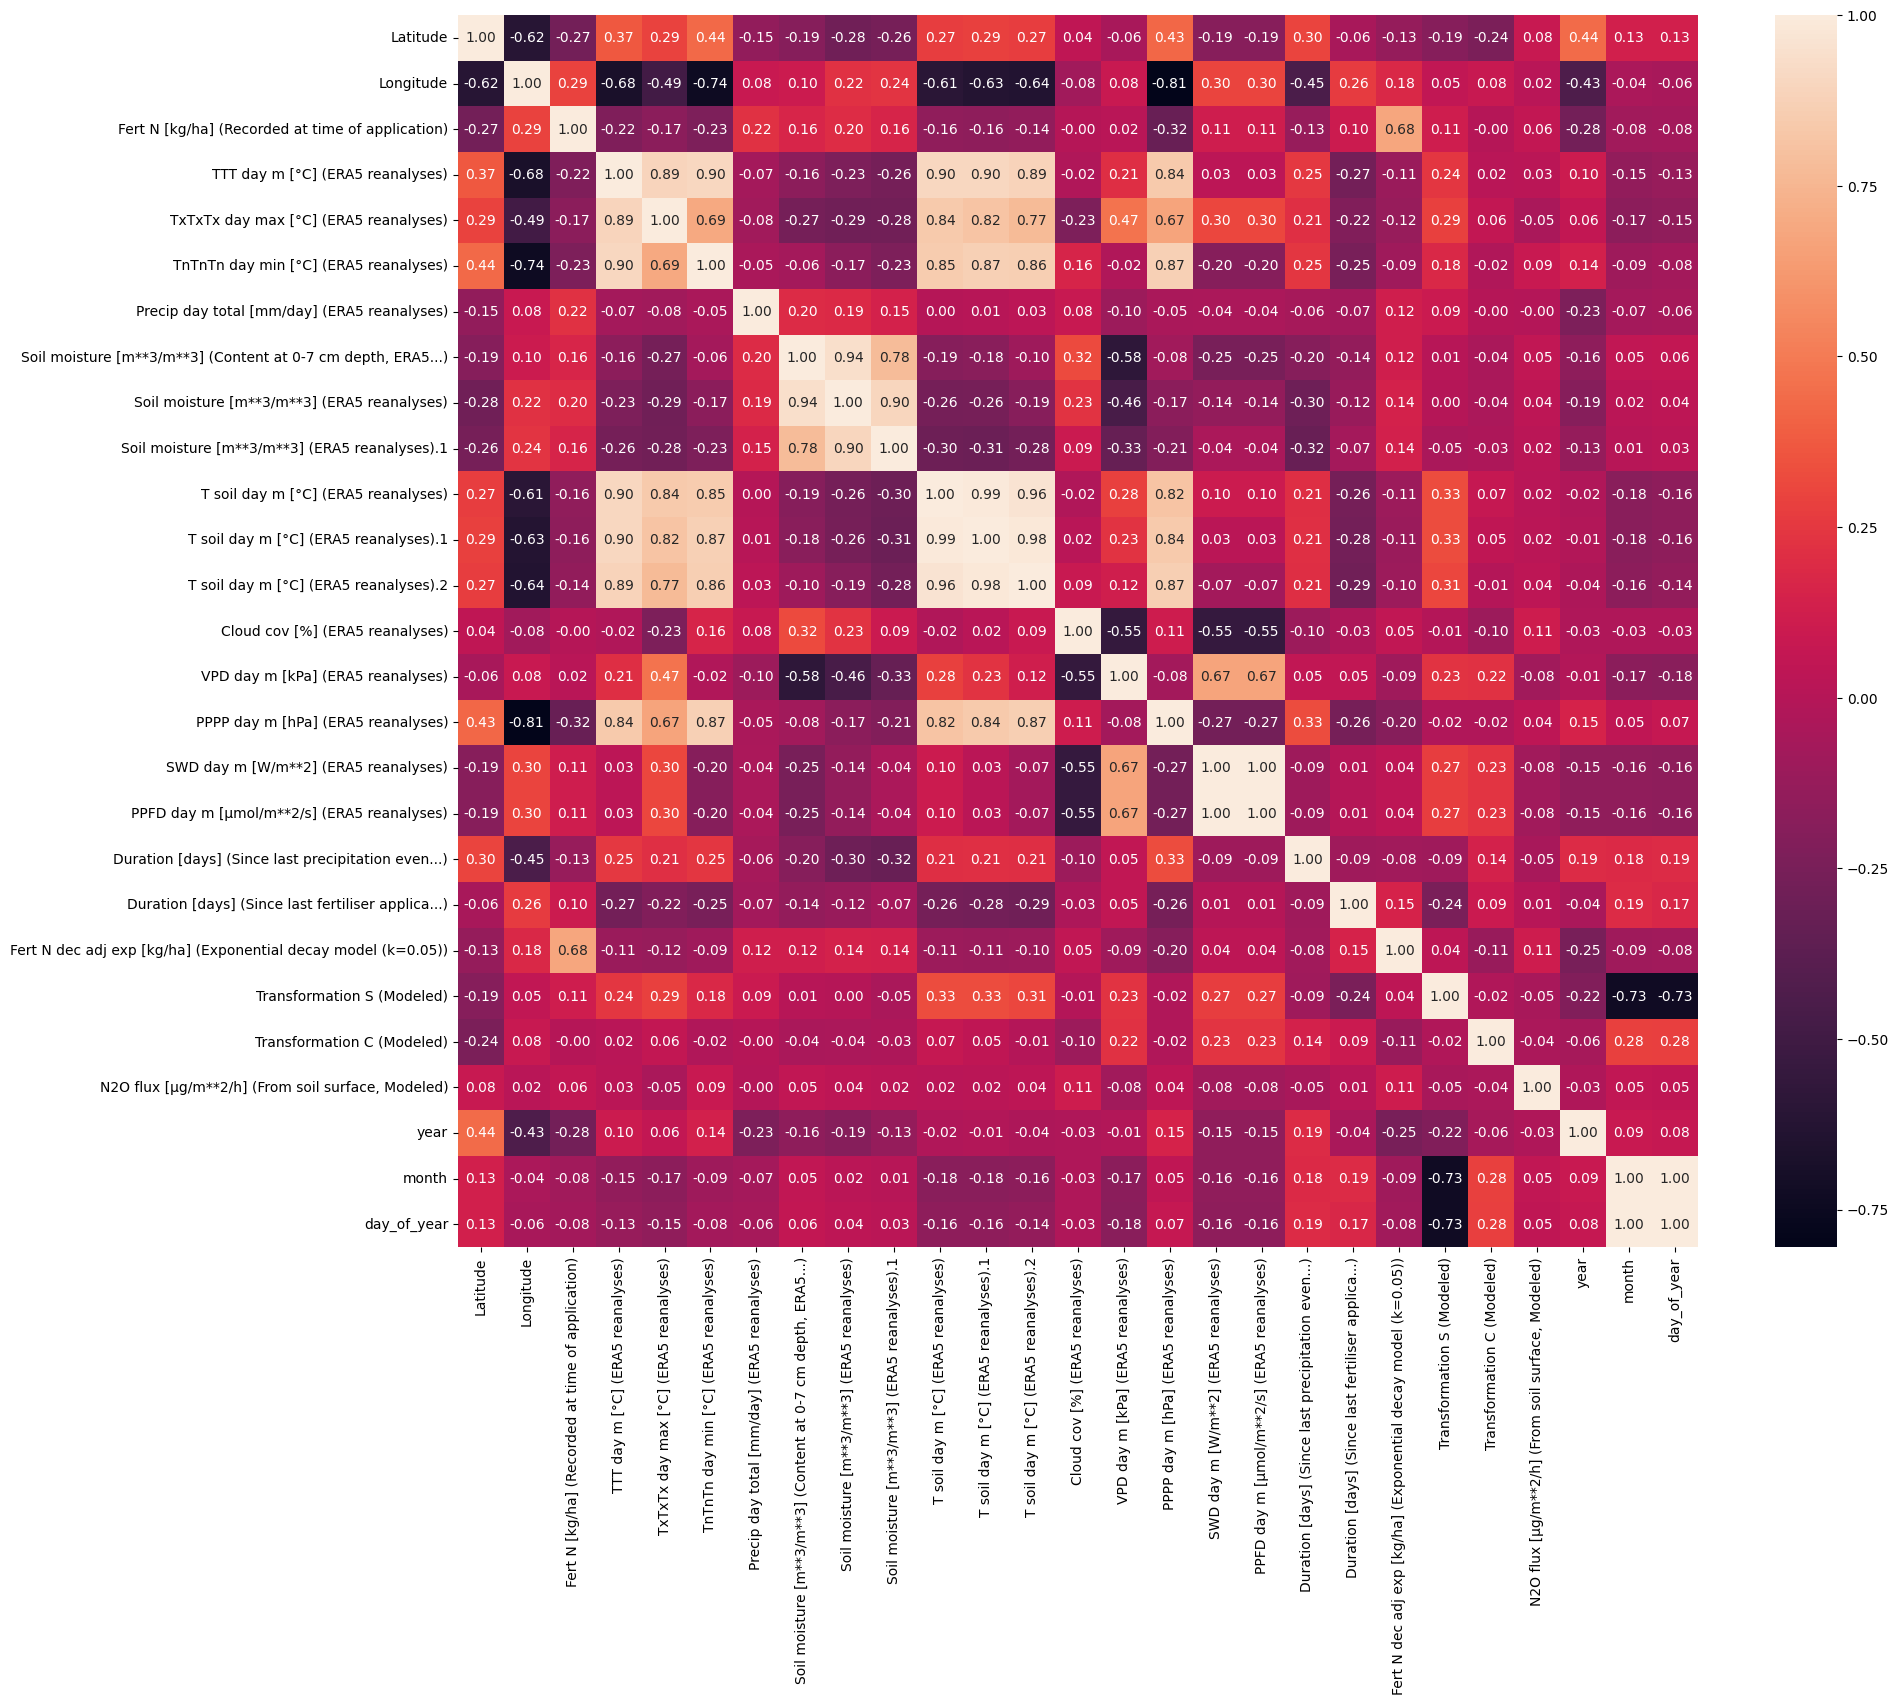

In [29]:

corr_matrix = df.loc[:,df.select_dtypes(include= [np.number]).columns].corr()

plt.figure(figsize = (20, 16))
sns.heatmap(corr_matrix, annot= True, linewidths=0, fmt= '.2f')

# 16. Summary

In [30]:
def summarize_dataframe(
    dataframe: pd.DataFrame,
    target_column: Optional[str] = None,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Create a compact summary table for all columns in a dataframe.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Input dataframe to summarize.
    target_column : Optional[str], default=None
        Optional target column name. If provided, a warning is printed if the column is missing.
    verbose : bool, default=False
        If True, print detailed information about the summary creation process.

    Returns
    -------
    pd.DataFrame
        Summary dataframe containing dtype, missing values, uniqueness, and example values.

    Raises
    ------
    TypeError
        If the input is not a pandas DataFrame.
    ValueError
        If the dataframe is empty.
    """
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame.")

    if dataframe.empty:
        raise ValueError("Input dataframe must not be empty.")

    if target_column is not None and target_column not in dataframe.columns:
        print(f"Warning: Target column not found: {target_column}")

    if verbose:
        print(f"Creating summary for dataframe with shape: {dataframe.shape}")

    summary = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "missing_count": dataframe.isna().sum(),
        "missing_percent": dataframe.isna().mean() * 100,
        "unique_count": dataframe.nunique(dropna=True),
        "unique_percent": dataframe.nunique(dropna=True) / len(dataframe) * 100,
    })

    summary["example_values"] = [
        dataframe[column].dropna().unique()[:5].tolist()
        for column in dataframe.columns
    ]

    summary = summary.reset_index().rename(columns={"index": "column"})

    if verbose:
        print("Summary creation completed.")

    return summary

In [31]:
summary_table = summarize_dataframe(
    dataframe=df,
    target_column=TARGET_COLUMN,
    verbose=True,
)

summary_table

Creating summary for dataframe with shape: (5280, 30)
Summary creation completed.


,column,dtype,missing_count,missing_percent,unique_count,unique_percent,example_values
0,Event,object,0,0.0,33,0.625000,"[17AG-KILO-FLM, 17AG-KILO-COF, 17AG-KILO-FOC, ..."
1,Latitude,float64,0,0.0,27,0.511364,"[-3.1651, -3.2454, -3.1424, 0.3219, -2.1399]"
2,Longitude,float64,0,0.0,27,0.511364,"[37.2354, 37.3195, 37.2423, 25.291, 27.8963]"
3,Date/Time,datetime64[ns],0,0.0,1447,27.405303,"[2011-03-10 00:00:00, 2011-03-17 00:00:00, 201..."
4,Land use,object,0,0.0,3,0.056818,"[Forest, Cropland, Grassland]"
5,Fert N [kg/ha] (Recorded at time of application),int64,0,0.0,9,0.170455,"[0, 120, 100, 200, 50]"
6,TTT day m [°C] (ERA5 reanalyses),float64,0,0.0,2493,47.215909,"[18.03048938, 17.54444291, 17.82332889, 16.740..."
7,TxTxTx day max [°C] (ERA5 reanalyses),float64,0,0.0,2217,41.988636,"[23.11734335, 20.26443183, 20.75704627, 19.703..."
8,TnTnTn day min [°C] (ERA5 reanalyses),float64,0,0.0,2162,40.946970,"[12.34032515, 15.17000975, 15.62918825, 15.208..."
9,Precip day total [mm/day] (ERA5 reanalyses),float64,0,0.0,1628,30.833333,"[0.067296834, 8.913425662, 0.358296457, 1.1305..."


In [38]:
print('data columns: ', [col for col in df.columns])

data columns:  ['Event', 'Latitude', 'Longitude', 'Date/Time', 'Land use', 'Fert N [kg/ha] (Recorded at time of application)', 'TTT day m [°C] (ERA5 reanalyses)', 'TxTxTx day max [°C] (ERA5 reanalyses)', 'TnTnTn day min [°C] (ERA5 reanalyses)', 'Precip day total [mm/day] (ERA5 reanalyses)', 'Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)', 'Soil moisture [m**3/m**3] (ERA5 reanalyses)', 'Soil moisture [m**3/m**3] (ERA5 reanalyses).1', 'T soil day m [°C] (ERA5 reanalyses)', 'T soil day m [°C] (ERA5 reanalyses).1', 'T soil day m [°C] (ERA5 reanalyses).2', 'Cloud cov [%] (ERA5 reanalyses)', 'VPD day m [kPa] (ERA5 reanalyses)', 'PPPP day m [hPa] (ERA5 reanalyses)', 'SWD day m [W/m**2] (ERA5 reanalyses)', 'PPFD day m [µmol/m**2/s] (ERA5 reanalyses)', 'Duration [days] (Since last precipitation even...)', 'Duration [days] (Since last fertiliser applica...)', 'Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05))', 'Transformation S (Modeled)', 'Transformation C (Modeled)'